In [9]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("notebook.ipynb")))

In [13]:

import dataclasses
from logging import Logger
import random
import os
from typing import Callable, Iterator
import jax
import jax.numpy as jnp
import torch
import numpy as np
import toolz
import math
import equinox as eqx
import threading
import time
import queue

from meta_learn_lib.checkpoint import CheckpointManager, CheckpointMetadata, NullCheckpointManager
from meta_learn_lib.config import *
from meta_learn_lib.create_env import create_env, create_inference_axes, create_transition_fns
from meta_learn_lib.create_interface import build_interfaces
from meta_learn_lib.env import *
from meta_learn_lib.inference import create_inference_and_readout
from meta_learn_lib.interface import GodInterface
from meta_learn_lib.learning import create_meta_learner
from meta_learn_lib.lib_types import *
from meta_learn_lib.datasets import create_data_sources, create_dataloader, get_seq_len, validate_dataloader_config
from meta_learn_lib.logger import MatplotlibLogger, create_logger
from meta_learn_lib.loss_function import create_readout_loss_fns
from meta_learn_lib.sample import make_sample_config, report_samples, validate_sample_generators
from configs import *
from meta_learn_lib.config_converter import make_converter






In [53]:
config = VAE_BASELINE_MLP
converter = make_converter()
config = converter.structure(converter.unstructure(config), GodConfig)

In [54]:
env_prng = PRNG(jax.random.fold_in(jax.random.key(config.seed.global_seed), config.seed.parameter_seed))
data_sources, shapes = create_data_sources(config, jax.random.key(config.seed.data_seed))
env = create_env(config, shapes, env_prng)

In [55]:
arr, static = eqx.partition(env, eqx.is_array)

In [57]:
import clearml
import string
from meta_learn_lib.checkpoint import ClearMLCheckpointManager

task = clearml.Task.create(
        project_name="temp",
        task_name="".join(random.choices(string.ascii_lowercase + string.digits, k=8)),
        task_type=clearml.TaskTypes.training,
    )


ckpt_dir = os.path.join(config.data_root_dir, "checkpoints", task.task_id)
checkpoint_manager = ClearMLCheckpointManager(task, ckpt_dir, initial_model_id="5913a0beaa854cc68462149792b959c7")

In [58]:
loaded = checkpoint_manager.load(arr)
arr, meta = loaded

In [59]:
env_loaded = eqx.combine(arr, static)

In [61]:
from meta_learn_lib.inference import create_raw_inference

sg = config.sample_generators[3]
sg_config = dataclasses.replace(
    config,
    nodes=config.nodes | sg.source_nodes,
    aliases=config.aliases | sg.aliases,
)
local_interfaces = build_interfaces(sg_config)
_, readout_fn = create_raw_inference(
    sg.transition_graph,
    sg.readout_graph,
    sg_config.nodes,
    sg_config.aliases,
    local_interfaces,
    0,
)


In [62]:
example = jax.random.normal(jax.random.PRNGKey(0), (2,)) 
env, output = readout_fn(env_loaded, (example, example))

In [63]:
output.prediction.shape

(1, 28, 28)

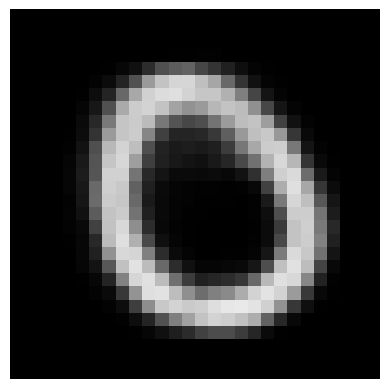

In [64]:
import matplotlib.pyplot as plt

img = np.asarray(output.prediction).squeeze(0)  # (28, 28)
plt.imshow(img, cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.show()

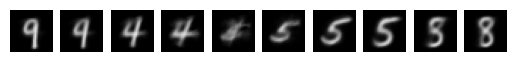

In [65]:
xs = jnp.linspace(-1, 1, 10) 
ys = jnp.zeros_like(xs)

results = []
for x, y in zip(xs, ys):
    example = jnp.array([x, y])
    env, output = readout_fn(env_loaded, (example, example))
    results.append(output.prediction)

fig, ax = plt.subplots(1, 10)
for i, (x, y) in enumerate(zip(xs, ys)):
    img = np.asarray(results[i]).squeeze(0)  # (28, 28)
    ax[i].imshow(img, cmap="gray", vmin=0, vmax=1, extent=(x-0.05, x+0.05, y-0.05, y+0.05))
    ax[i].axis("off")

plt.show()

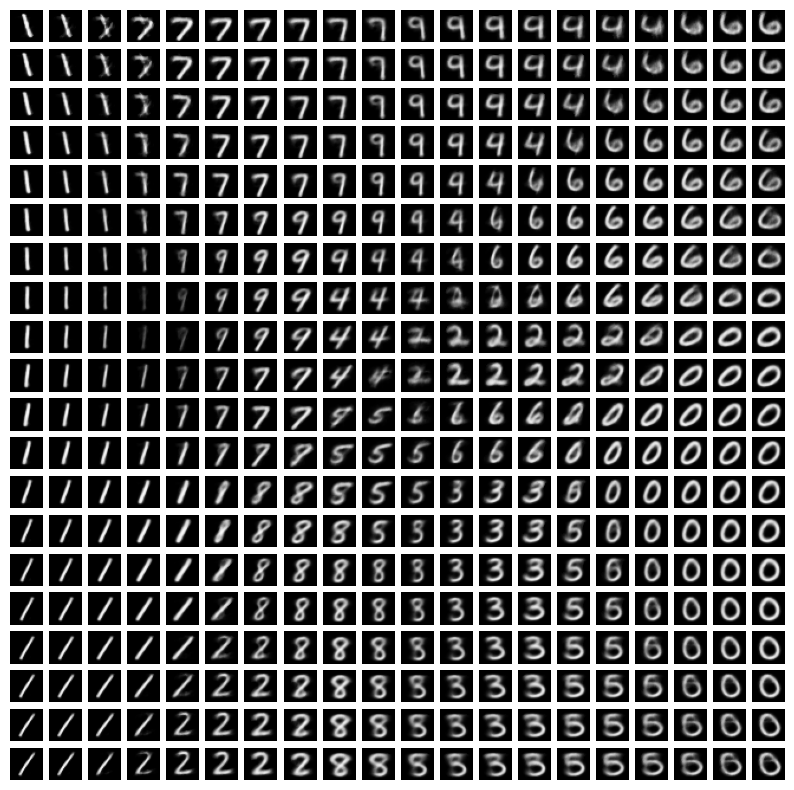

In [66]:
xs = jnp.linspace(-2, 2, 20) 
ys = jnp.linspace(-2, 2, 20) 

results = [[None for _ in ys] for _ in xs]
for i, x in enumerate(xs):
    for j, y in enumerate(ys):
        example = jnp.array([x, y])
        env, output = readout_fn(env_loaded, (example, example))
        results[i][j] = output.prediction

fig, ax = plt.subplots(20, 20, figsize=(10, 10))
for i, x in enumerate(xs):
    for j, y in enumerate(ys):
        img = np.asarray(results[i][j]).squeeze(0)  # (28, 28)
        ax[i,j].imshow(img, cmap="gray", vmin=0, vmax=1, extent=(x-0.05, x+0.05, y-0.05, y+0.05))
        ax[i, j].axis("off")

plt.show()
fig.tight_layout()